# 6CS012 Final Portfolio Project 2026
# Part III – Language Tasks: Hate Speech & Offensive Language Detection

**Task:** Text Classification (Sentiment/Hate Speech Analysis)  
**Labels:** `offensive_language`, `hate_speech`, `neither`  
**Models:** Simple RNN → LSTM → LSTM + Word2Vec Embeddings  
**Framework:** TensorFlow / Keras

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 0. Install Dependencies & Imports

In [2]:
# Run this cell first — installs required packages
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install wordcloud -q
!pip install nltk -q
!pip install contractions -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 101.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')


# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras / TF
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Gensim Word2Vec
import gensim.downloader as api

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU available      : True


---
## 1. Load Dataset

In [ ]:
CSV_PATH = '/content/drive/MyDrive/Ai and machine learning/assessment/hatevsoffensive_language.csv'

df = pd.read_csv(CSV_PATH)

# Standardise column names (lowercase, strip spaces)
df.columns = df.columns.str.strip().str.lower()

print(f"Dataset shape    : {df.shape}")
print(f"Columns          : {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nNull values:")
print(df.isnull().sum())
df.head()

Dataset shape    : (24783, 2)
Columns          : ['label', 'text']

Label distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Null values:
label    0
text     0
dtype: int64


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


---
## 2. Data Analysis & Visualization

### 2.1 Class Distribution

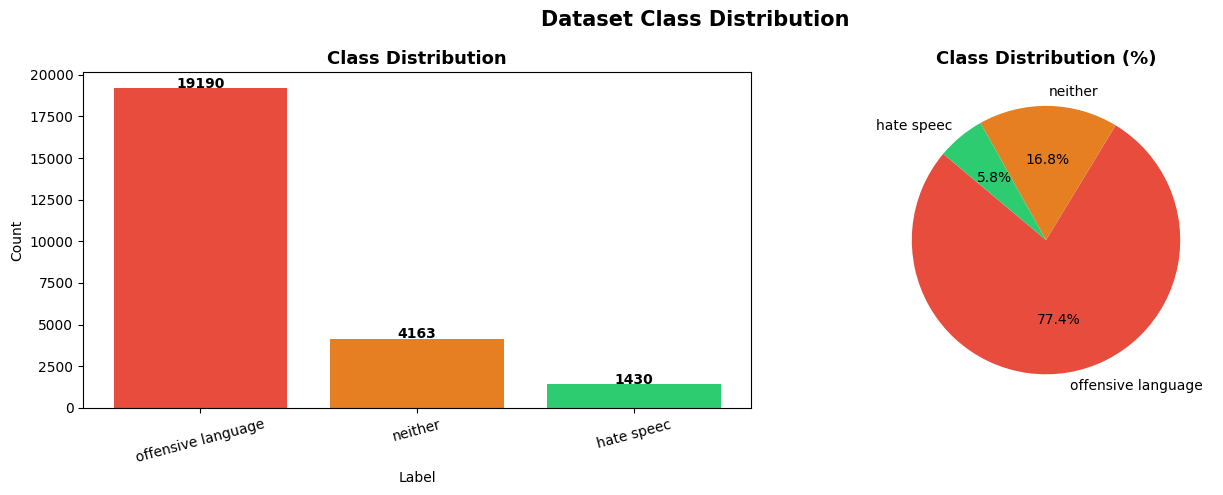

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#e67e22', '#2ecc71']

# Bar chart
counts = df['label'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

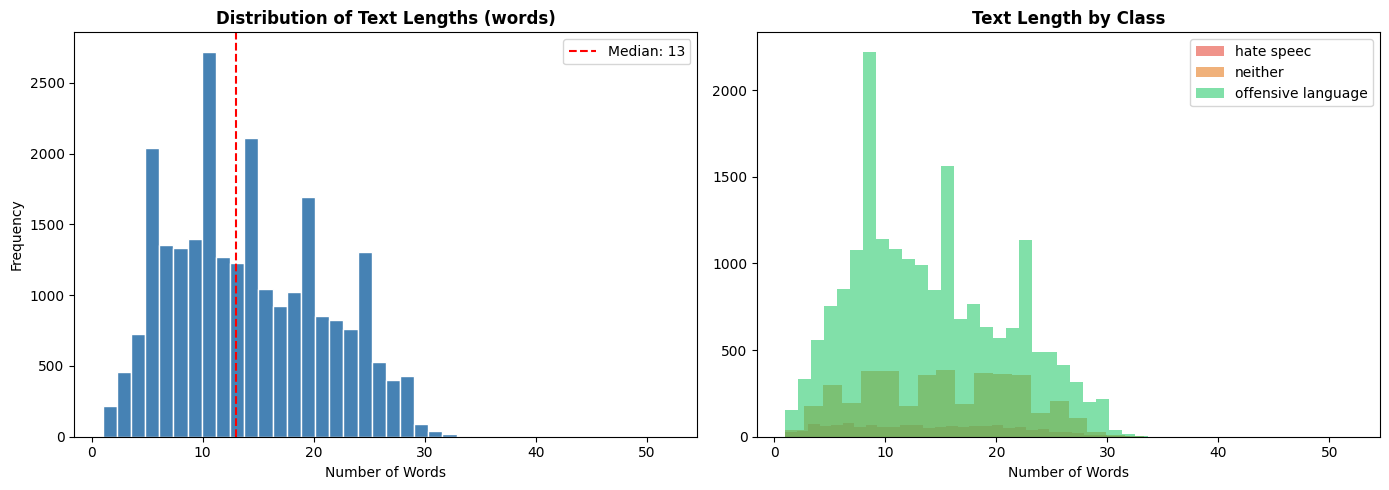

Mean text length   : 14.1 words
Median text length : 13 words
95th percentile    : 26 words


In [16]:
# ── Text length analysis ──────────────────────────────────────────────────────
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Text Lengths (words)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Words'); axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length'].median(), color='red', linestyle='--',
                label=f"Median: {df['text_length'].median():.0f}")
axes[0].legend()

# Length by class
for i, (label, group) in enumerate(df.groupby('label')):
    axes[1].hist(group['text_length'], bins=30, alpha=0.6, label=label, color=colors[i])
axes[1].set_title('Text Length by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Words'); axes[1].legend()

plt.tight_layout()
plt.savefig('text_lengths.png', bbox_inches='tight')
plt.show()

print(f"Mean text length   : {df['text_length'].mean():.1f} words")
print(f"Median text length : {df['text_length'].median():.0f} words")
print(f"95th percentile    : {np.percentile(df['text_length'], 95):.0f} words")

---
## 3. Text Preprocessing & Cleaning

Steps applied:
1. Lowercase all text
2. Remove URLs, mentions (@user), hashtags (#)
3. Remove numbers and special characters
4. Handle contractions
5. Remove stopwords
6. Lemmatize words

In [17]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))


def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = contractions.fix(text)               # contractions
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'\brt\b', '', text)                # remove RT  ← ADD THIS
    text = re.sub(r'#\w+', '', text)                  # remove hashtags
    text = re.sub(r'\d+', '', text)                   # remove numbers
    text = text.translate(
        str.maketrans('', '', string.punctuation))     # remove punctuation
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print("Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)
print("Done!")

# Show before/after
print("\nSample Before Cleaning:")
print(df['text'].iloc[0])
print("\nSample After Cleaning:")
print(df['clean_text'].iloc[0])

Cleaning text...
Done!

Sample Before Cleaning:
!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...

Sample After Cleaning:
woman complain cleaning house amp man always take trash


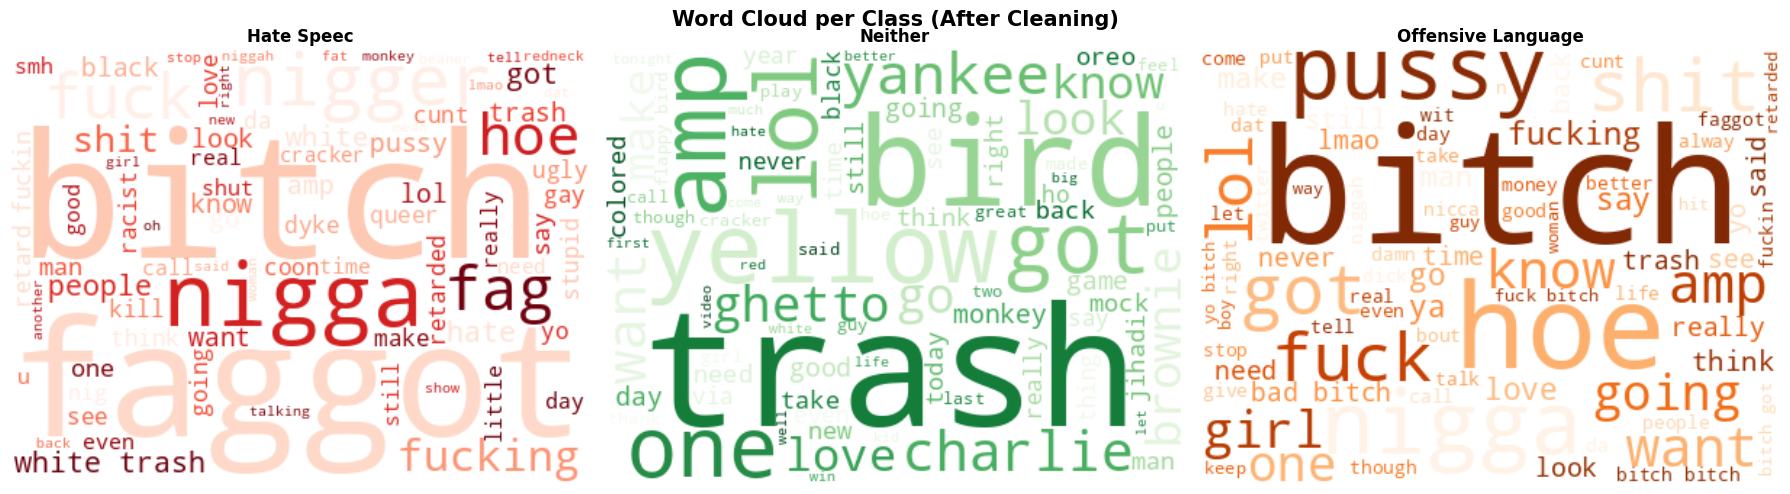

In [18]:
# ── Word Cloud Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
label_list = df['label'].unique()

for ax, label, color in zip(axes, sorted(label_list), colors):
    text_combined = ' '.join(df[df['label'] == label]['clean_text'].values)
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap='Reds' if 'hate' in label else
                   'Oranges' if 'offensive' in label else 'Greens',
                   max_words=80).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Cloud per Class (After Cleaning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()

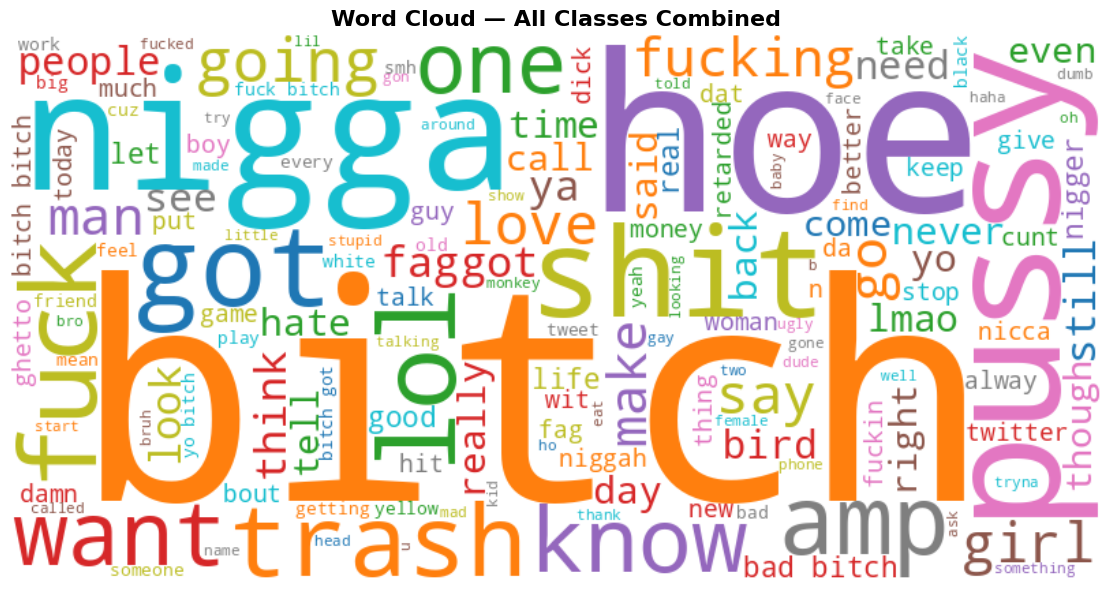

In [19]:
# ── Word Cloud — All Classes Combined ────────────────────────────────────────
all_text = ' '.join(df['clean_text'].values)

wc_all = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='tab10',
    max_words=150
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Classes Combined', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_all.png', bbox_inches='tight')
plt.show()

---
## 4. Tokenization, Label Encoding & Padding

In [20]:
# ── Label encoding ────────────────────────────────────────────────────────────
LABEL_MAP = {'hate_speech': 0, 'offensive_language': 1, 'neither': 2}

# Fix inconsistent labels in the 'label' column to match LABEL_MAP keys
df['label'] = df['label'].replace({'offensive language': 'offensive_language',
                                   'hate speec': 'hate_speech'})

df['label_encoded'] = df['label'].map(LABEL_MAP)
NUM_CLASSES = len(LABEL_MAP)
print(f"Label mapping: {LABEL_MAP}")

# ── Train / Test split (80/20) ────────────────────────────────────────────────
X = df['clean_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")

Label mapping: {'hate_speech': 0, 'offensive_language': 1, 'neither': 2}

Train size : 19826
Test size  : 4957


In [21]:
# ── Tokenization ──────────────────────────────────────────────────────────────
VOCAB_SIZE   = 10000
OOV_TOKEN    = '<OOV>'   # out-of-vocabulary token

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)   # fit only on training data

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
print(f"Vocabulary size (unique words): {len(word_index)}")

# ── Padding ───────────────────────────────────────────────────────────────────
# Use 95th percentile to avoid overly long sequences
all_lengths  = [len(seq) for seq in X_train_seq]
MAX_LEN      = int(np.percentile(all_lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

Vocabulary size (unique words): 16059
Max sequence length (95th percentile): 14

X_train_pad shape : (19826, 14)
X_test_pad shape  : (4957, 14)


---
## 5. Model 1 — Simple RNN with Trainable Embedding

In [22]:
EMBEDDING_DIM = 64

def build_rnn_model():
    model = models.Sequential(name='Simple_RNN')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE,
                               output_dim=EMBEDDING_DIM,
                               input_length=MAX_LEN))
    model.add(layers.SimpleRNN(64, return_sequences=False))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Simple RNN...")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1),
               ModelCheckpoint('best_rnn.keras', monitor='val_loss',
                        save_best_only=True, verbose=1)
               ]
)

# Load best saved model
rnn_model = keras.models.load_model('best_rnn.keras')
print("Best RNN model loaded.")

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN...
Epoch 1/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8285 - loss: 0.5083
Epoch 1: val_loss improved from None to 0.30897, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8575 - loss: 0.4162 - val_accuracy: 0.8931 - val_loss: 0.3090
Epoch 2/20
550/558 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9141 - loss: 0.2484
Epoch 2: val_loss did not improve from 0.30897
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9123 - loss: 0.2580 - val_accuracy: 0.8870 - val_loss: 0.3159
Epoch 3/20
549/558 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9435 - loss: 0.1696
Epoch 3: val_loss did not improve from 0.30897
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9396 - loss: 0.1757 - val_accuracy: 0.8921 - val_loss: 0.3554
Epoch 4/20
556/558 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9681 - loss: 0.1056
Epoch 4: val_loss did not improve from 0.30897
558/558 ━

---
## 6. Model 2 — LSTM with Trainable Embedding

In [23]:
def build_lstm_model():
    model = models.Sequential(name='LSTM_Model')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE,
                               output_dim=EMBEDDING_DIM,
                               input_length=MAX_LEN))
    model.add(layers.LSTM(128, return_sequences=True))
    model.add(layers.Dropout(0.3))
    model.add(layers.LSTM(64))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining LSTM...")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1),
               ModelCheckpoint('best_lstm.keras', monitor='val_loss',
                        save_best_only=True, verbose=1)
               ]
)

# Load best saved model
lstm_model = keras.models.load_model('best_lstm.keras')
print("Best LSTM model loaded.")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/20
556/558 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8257 - loss: 0.5234
Epoch 1: val_loss improved from None to 0.30756, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8602 - loss: 0.4066 - val_accuracy: 0.8931 - val_loss: 0.3076
Epoch 2/20
553/558 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9073 - loss: 0.2750
Epoch 2: val_loss did not improve from 0.30756
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9105 - loss: 0.2673 - val_accuracy: 0.8749 - val_loss: 0.3158
Epoch 3/20
555/558 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9310 - loss: 0.2061
Epoch 3: val_loss did not improve from 0.30756
558/558 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9321 - loss: 0.2070 - val_accuracy: 0.8830 - val_loss: 0.3448
Epoch 4/20
556/558 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9489 - loss: 0.1615
Epoch 4: val_loss did not improve from 0.30756
558/558 ━

---
## 7. Model 3 — LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [24]:
# ── Load pre-trained GloVe embeddings (50-dimensional) ───────────────────────
# This may take a few minutes to download on first run
print("Loading GloVe embeddings (this may take a few minutes)...")
embedding_model = api.load('glove-wiki-gigaword-50')
W2V_DIM = 50
print("GloVe loaded successfully!")

Loading GloVe embeddings (this may take a few minutes)...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded successfully!


In [25]:
# ── Build embedding matrix ────────────────────────────────────────────────────
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found = 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Words found in GloVe: {found} / {min(len(word_index), VOCAB_SIZE)}")
print(f"Embedding coverage  : {coverage:.1f}%")

Words found in GloVe: 8385 / 10000
Embedding coverage  : 83.9%


In [26]:
def build_lstm_w2v_model():
    model = models.Sequential(name='LSTM_Word2Vec')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=W2V_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False    # frozen — use pre-learned representations
    ))
    model.add(layers.LSTM(128, return_sequences=True))
    model.add(layers.Dropout(0.3))
    model.add(layers.LSTM(64))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

lstm_w2v_model = build_lstm_w2v_model()
lstm_w2v_model.summary()

lstm_w2v_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining LSTM + Word2Vec...")
history_lstm_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1),
               ModelCheckpoint('best_lstm_w2v.keras', monitor='val_loss',
                        save_best_only=True, verbose=1)
               ]
)

# Load best saved model
lstm_w2v_model = keras.models.load_model('best_lstm_w2v.keras')
print("Best LSTM+Word2Vec model loaded.")

Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)


Training LSTM + Word2Vec...
Epoch 1/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8195 - loss: 0.5114
Epoch 1: val_loss improved from None to 0.33928, saving model to best_lstm_w2v.keras

Epoch 1: finished saving model to best_lstm_w2v.keras
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8466 - loss: 0.4245 - val_accuracy: 0.8643 - val_loss: 0.3393
Epoch 2/20
554/558 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8697 - loss: 0.3389
Epoch 2: val_loss improved from 0.33928 to 0.30844, saving model to best_lstm_w2v.keras

Epoch 2: finished saving model to best_lstm_w2v.keras
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8697 - loss: 0.3314 - val_accuracy: 0.8739 - val_loss: 0.3084
Epoch 3/20
556/558 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8826 - loss: 0.2966
Epoch 3: val_loss did not improve from 0.30844
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8805 - loss: 0.3047 - val_accuracy: 0.8785 - val_loss: 0.3279
Epoch 4/20
558/558 ━━━━━━━━━━━

---
## 8. Training Curves — All Models Compared

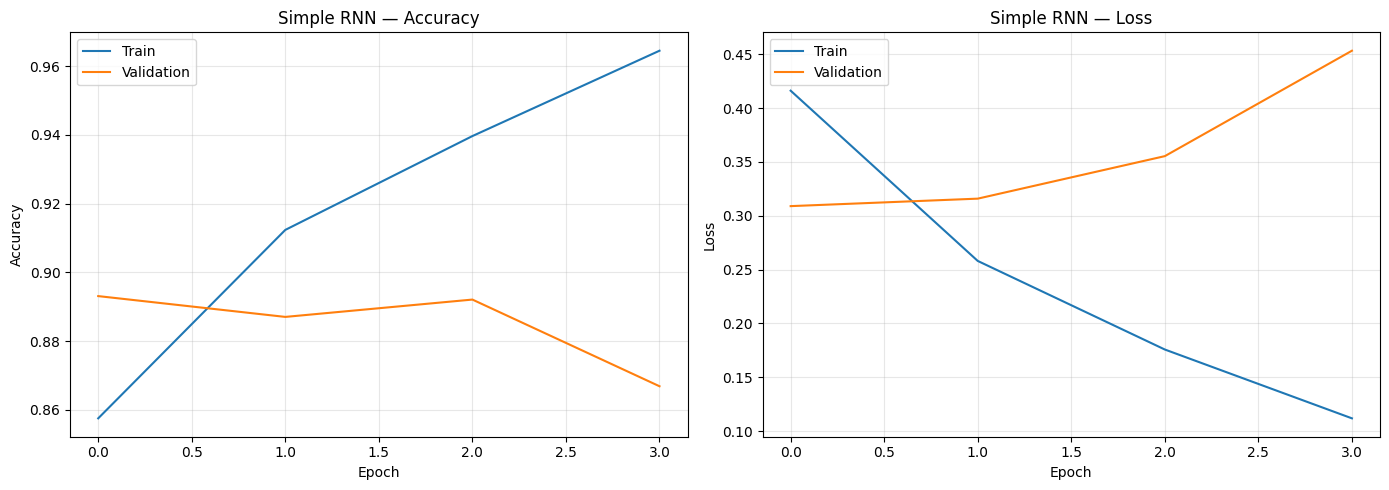

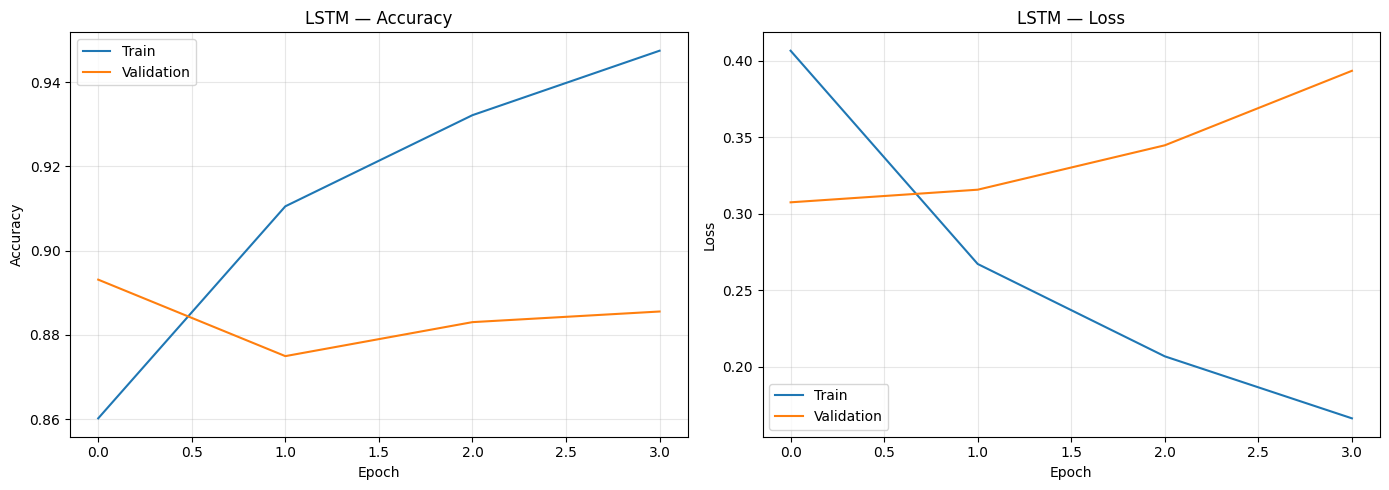

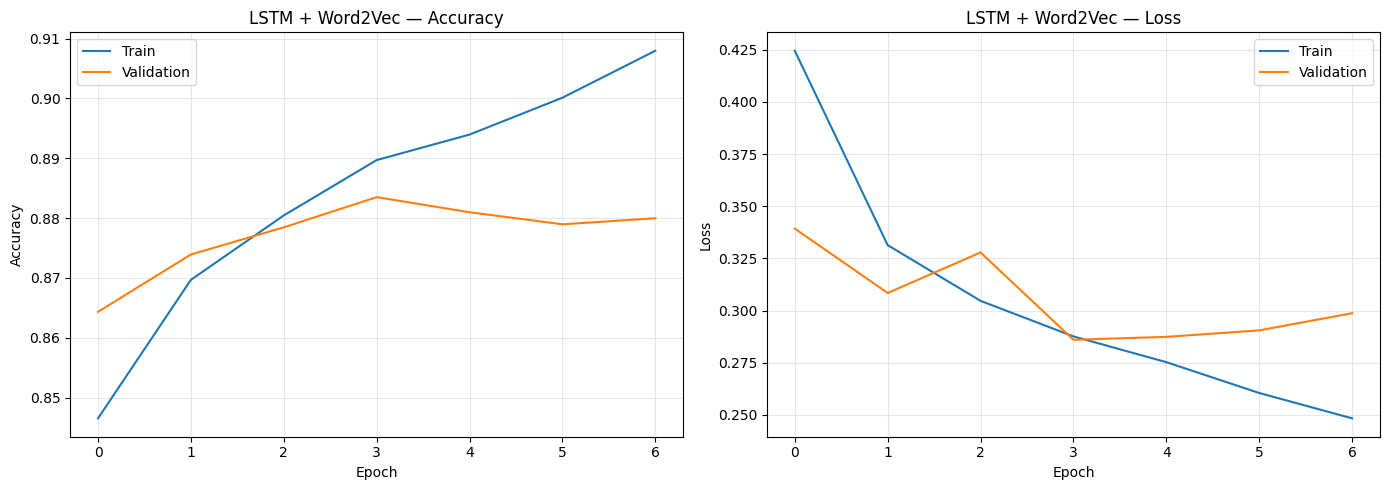

In [27]:
def plot_history(history, title, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, bbox_inches='tight')
    plt.show()

plot_history(history_rnn,      'Simple RNN',       'rnn_curves.png')
plot_history(history_lstm,     'LSTM',             'lstm_curves.png')
plot_history(history_lstm_w2v, 'LSTM + Word2Vec',  'lstm_w2v_curves.png')

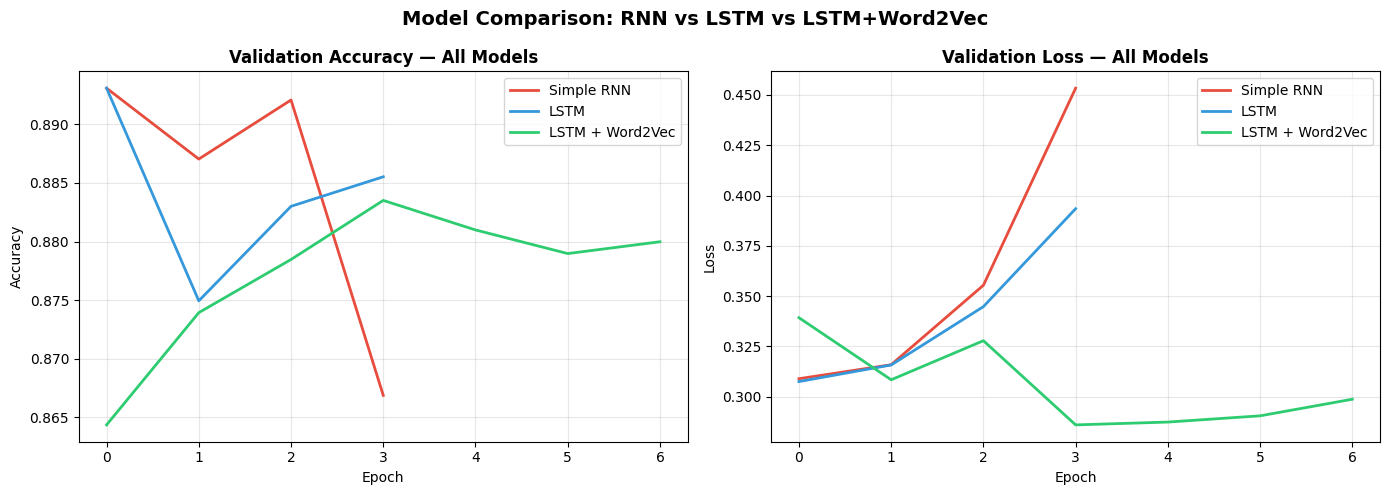

In [28]:
# ── Overlay comparison of all 3 val_accuracy curves ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [
    (history_rnn,      'Simple RNN',      '#e74c3c'),
    (history_lstm,     'LSTM',            '#3498db'),
    (history_lstm_w2v, 'LSTM + Word2Vec', '#2ecc71')
]:
    axes[0].plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2)
    axes[1].plot(hist.history['val_loss'],     label=label, color=color, linewidth=2)

axes[0].set_title('Validation Accuracy — All Models', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss — All Models', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: RNN vs LSTM vs LSTM+Word2Vec',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

---
## 9. Model Evaluation — Accuracy, Confusion Matrix, Classification Report


Simple RNN
  Test Accuracy : 88.70%
  Test Loss     : 0.3266

Classification Report:
                    precision    recall  f1-score   support

       hate_speech       0.00      0.00      0.00       286
offensive_language       0.92      0.95      0.93      3838
           neither       0.76      0.91      0.83       833

          accuracy                           0.89      4957
         macro avg       0.56      0.62      0.59      4957
      weighted avg       0.84      0.89      0.86      4957



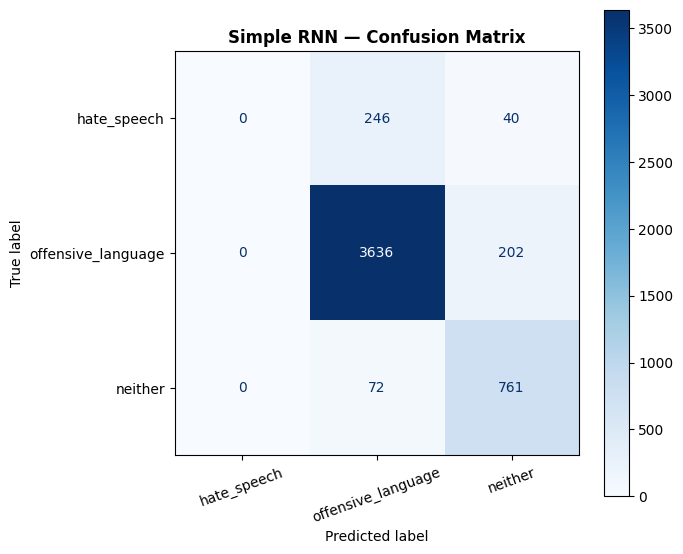


LSTM
  Test Accuracy : 88.44%
  Test Loss     : 0.3286

Classification Report:
                    precision    recall  f1-score   support

       hate_speech       0.00      0.00      0.00       286
offensive_language       0.91      0.96      0.93      3838
           neither       0.78      0.85      0.81       833

          accuracy                           0.88      4957
         macro avg       0.56      0.60      0.58      4957
      weighted avg       0.83      0.88      0.86      4957



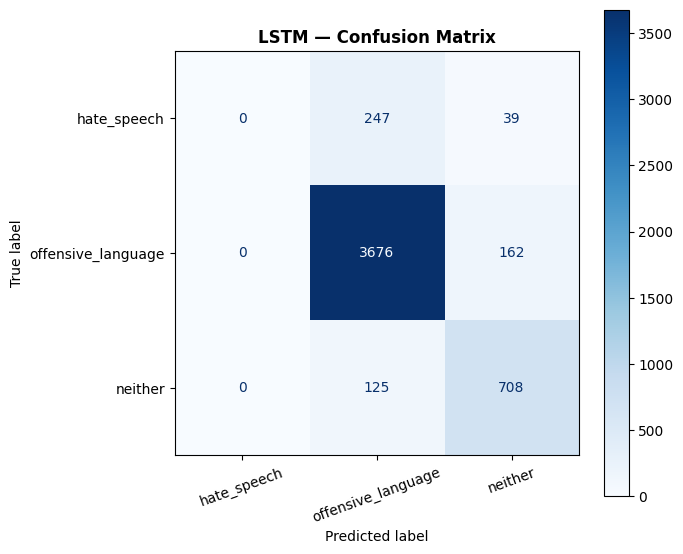


LSTM + Word2Vec
  Test Accuracy : 87.90%
  Test Loss     : 0.3001

Classification Report:
                    precision    recall  f1-score   support

       hate_speech       0.47      0.19      0.27       286
offensive_language       0.91      0.94      0.93      3838
           neither       0.78      0.82      0.80       833

          accuracy                           0.88      4957
         macro avg       0.72      0.65      0.67      4957
      weighted avg       0.87      0.88      0.87      4957



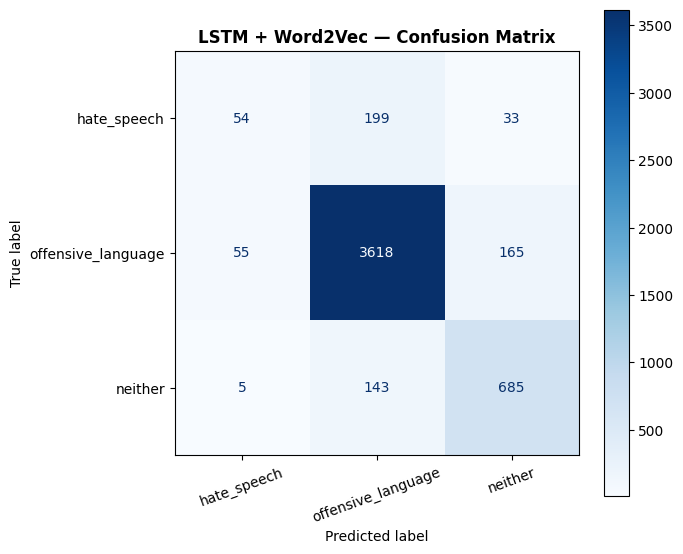

In [29]:
LABEL_NAMES = ['hate_speech', 'offensive_language', 'neither']

def evaluate_model(model, X_test, y_test, model_name):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n{'='*55}")
    print(f"{model_name}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, xticks_rotation=20, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_cm.png', bbox_inches='tight')
    plt.show()

    return acc, loss, y_pred

rnn_acc,  rnn_loss,  rnn_preds  = evaluate_model(rnn_model,      X_test_pad, y_test, 'Simple RNN')
lstm_acc, lstm_loss, lstm_preds = evaluate_model(lstm_model,     X_test_pad, y_test, 'LSTM')
w2v_acc,  w2v_loss,  w2v_preds  = evaluate_model(lstm_w2v_model, X_test_pad, y_test, 'LSTM + Word2Vec')

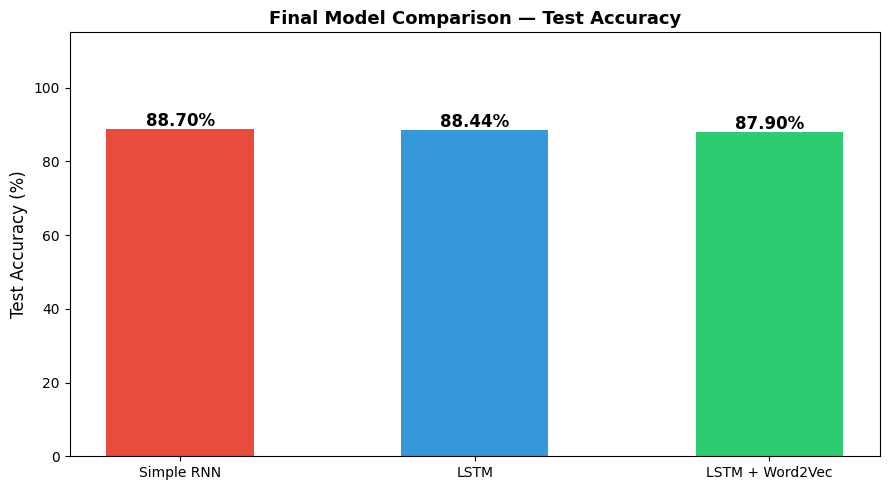


Summary:
  Simple RNN           88.70%
  LSTM                 88.44%
  LSTM + Word2Vec      87.90%


In [30]:
# ── Final accuracy bar chart ──────────────────────────────────────────────────
model_names = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
accs        = [rnn_acc*100, lstm_acc*100, w2v_acc*100]
bar_colors  = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, accs, color=bar_colors, width=0.5)
ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

print("\nSummary:")
for name, acc in zip(model_names, accs):
    print(f"  {name:<20} {acc:.2f}%")

---
## 10. Error Analysis

In [31]:
# ── Misclassified examples from best model (LSTM + Word2Vec) ─────────────────
X_test_original = df['text'].values[len(X_train):]   # original (uncleaned) texts
X_test_original = df['clean_text'].values[len(X_train):]   # original (uncleaned) texts
y_pred_best     = w2v_preds

errors = [(X_test_original[i], LABEL_NAMES[y_test[i]], LABEL_NAMES[y_pred_best[i]])
          for i in range(len(y_test)) if y_test[i] != y_pred_best[i]]

print(f"Total misclassified: {len(errors)} / {len(y_test)}")
print(f"\n--- 3 Sample Misclassifications (LSTM + Word2Vec) ---\n")
for i, (text, true, pred) in enumerate(errors[:3]):
    print(f"Example {i+1}:")
    print(f"  Text      : {text[:120]}...")
    print(f"  True Label: {true}")
    print(f"  Predicted : {pred}")
    print()

Total misclassified: 600 / 4957

--- 3 Sample Misclassifications (LSTM + Word2Vec) ---

Example 1:
  Text      : preferring barefoot make basic bitch sign get free mason jar...
  True Label: hate_speech
  Predicted : offensive_language

Example 2:
  Text      : raven symones hair like colored american...
  True Label: offensive_language
  Predicted : neither

Example 3:
  Text      : bitch real...
  True Label: offensive_language
  Predicted : neither



**Possible reasons for misclassification:**
- Hate speech and offensive language share very similar vocabulary, making the boundary hard to learn.
- Sarcasm and context-dependent language are difficult to capture with fixed embeddings.
- Class imbalance may cause the model to bias towards the majority class.

**Potential improvements:**
- Use a Bidirectional LSTM to capture context from both directions.
- Use larger pre-trained embeddings (300-dimensional Word2Vec or GloVe).
- Apply class weights during training to handle imbalanced classes.
- Use transformer-based models (BERT) for better contextual understanding.

---
## 11. GUI — Real-Time Prediction (Gradio)

> **This section is optional (extra marks).** Run the cell below to launch the Gradio interface.
> If Gradio is not installed, run: `!pip install gradio -q`

In [32]:
# ── WITHOUT Gradio — Simple command-line prediction function ──────────────────
def predict_text(text, model=lstm_w2v_model):
    """Predict the label of a given text string."""
    cleaned  = clean_text(text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = model.predict(padded, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = LABEL_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    print(f"\nInput     : {text}")
    print(f"Prediction: {pred_label} ({confidence:.1f}% confidence)")
    print("All scores:")
    for label, prob in zip(LABEL_NAMES, probs):
        print(f"  {label:<25}: {prob*100:.2f}%")
    return pred_label, confidence

# Test it
predict_text("I love everyone and wish everyone peace")
predict_text("You are the worst person I have ever met")


Input     : I love everyone and wish everyone peace
Prediction: neither (84.8% confidence)
All scores:
  hate_speech              : 1.58%
  offensive_language       : 13.59%
  neither                  : 84.83%

Input     : You are the worst person I have ever met
Prediction: neither (50.0% confidence)
All scores:
  hate_speech              : 7.13%
  offensive_language       : 42.84%
  neither                  : 50.03%


('neither', np.float32(50.0328))

In [33]:
# ── WITH Gradio — Interactive Web Interface ────────────────────────────────────
# Uncomment and run this cell to launch the Gradio GUI

!pip install gradio -q
import gradio as gr

def gradio_predict(text):
    cleaned  = clean_text(text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = lstm_w2v_model.predict(padded, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = LABEL_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100
    result = {
        label: float(prob)
        for label, prob in zip(LABEL_NAMES, probs)
    }
    return f"Prediction: {pred_label} ({confidence:.1f}% confidence)", result

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type a tweet or sentence here...",
        label="Input Text"
    ),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(label="Class Probabilities")
    ],
    title="Hate Speech & Offensive Language Detector",
    description="Enter a text and the model will classify it as: "
                "hate_speech | offensive_language | neither",
    examples=[
        ["I love everyone and wish peace to the world"],
        ["You are absolutely terrible and should be ashamed"],
        ["Happy to see people helping each other today"]
    ]
)

interface.launch(share=True)   # share=True gives a public URL on Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://25f3a55b2517e678e8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
